In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import io

In [133]:
whiteouts = pd.read_csv('white_out_plays.csv')
penn_plays = pd.read_csv('penn_state_plays.csv')
penn_games = pd.read_csv('penn_state_plays.csv')
oregon_games = pd.read_csv('oregon_games_data.csv')
plays = pd.read_csv('p4_p4_plays.csv')

# penn_games.columns

C:\Users\bchm5\AppData\Local\Temp\ipykernel_9828\3286598725.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv('p4_p4_plays.csv')


In [134]:
def get_past_tendencies(df, label):
    df = df.copy()
    
    numeric_cols = ['success', 'touchdown', 'turnover', 'off_penalty', 'def_penalty',
                    'interception', 'fumble', 'motion', 'shift', 'play_action', 'pressure',
                    'sack', 'blitz_dog', 'mug_look', 'box_players_count', 'no_huddle',
                    'tempo', 'unbalanced', 'screen', 'draw', 'trick_play', 'trick_look',
                    'expected_points_added', 'gain_loss', 'first_down_gained', 'option',
                    'run_pass_option', 'stunt', 'safety_count', 'box_players_on_los_count',
                    'defensive_line_shift', 'pass_breakup', 'missed_tackle', 'blitz_dog']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # offensive tendencies — gameplan decisions
    past_offense = df[df['offense'] == 'PAST'].copy()
    past_offense['first_down_gained_numeric'] = past_offense['first_down_gained'].fillna(0)

    past_offense_by_game = past_offense.groupby(['season', 'week', 'pff_game_id']).agg(
        off_plays=('pff_play_id', 'size'),
        # run/pass gameplan
        pass_rate=('run_pass', lambda x: (x == 'P').mean()),
        run_rate=('run_pass', lambda x: (x == 'R').mean()),
        # pre-snap decisions
        motion_rate=('motion', 'mean'),
        shift_rate=('shift', 'mean'),
        no_huddle_rate=('no_huddle', 'mean'),
        tempo_rate=('tempo', 'mean'),
        unbalanced_rate=('unbalanced', 'mean'),
        # play design
        play_action_rate=('play_action', 'mean'),
        screen_rate=('screen', 'mean'),
        draw_rate=('draw', 'mean'),
        option_rate=('option', 'mean'),
        rpo_rate=('run_pass_option', 'mean'),
        trick_play_rate=('trick_play', 'mean'),
        trick_look_rate=('trick_look', 'mean'),
        # protection
        pressure_allowed_rate=('pressure', 'mean'),
        sack_allowed_rate=('sack', 'mean'),
        # penalties
        off_penalty_rate=('off_penalty', 'mean'),
    ).reset_index()

    # defensive tendencies — gameplan decisions
    past_defense = df[df['defense'] == 'PAST'].copy()

    past_defense_by_game = past_defense.groupby(['season', 'week', 'pff_game_id']).agg(
        def_plays=('pff_play_id', 'size'),
        # pass rush gameplan
        blitz_rate=('blitz_dog', 'mean'),
        stunt_rate=('stunt', 'mean'),
        pressure_generated_rate=('pressure', 'mean'),
        sack_generated_rate=('sack', 'mean'),
        # coverage/alignment
        box_count_avg=('box_players_count', 'mean'),
        box_los_count_avg=('box_players_on_los_count', 'mean'),
        safety_count_avg=('safety_count', 'mean'),
        mug_rate=('mug_look', 'mean'),
        def_line_shift_rate=('defensive_line_shift', 'mean'),
        # results
        pass_breakup_rate=('pass_breakup', 'mean'),
        missed_tackle_rate=('missed_tackle', 'mean'),
        def_penalty_rate=('def_penalty', 'mean'),
        opp_pass_rate=('run_pass', lambda x: (x == 'P').mean()),
        opp_run_rate=('run_pass', lambda x: (x == 'R').mean()),
        opp_motion_rate=('motion', 'mean'),
        opp_no_huddle_rate=('no_huddle', 'mean'),
    ).reset_index()

    past_by_game = pd.merge(past_offense_by_game, past_defense_by_game,
                             on=['season', 'week', 'pff_game_id'],
                             suffixes=('_off', '_def'))

    totals = past_by_game.mean(numeric_only=True)
    totals['season'] = 'TOTAL'
    totals['week'] = '-'
    totals['pff_game_id'] = '-'
    past_by_game = pd.concat([past_by_game, totals.to_frame().T], ignore_index=True)

    # not_included = ['play_action_rate', 'screen_rate', 'draw_rate', 'option_rate', 'rpo_rate', 'trick_play_rate', 'trick_look_rate', 'sack_allowed_rate', 
    #                 ]
    # included = ['season', 'pff_game_id', 'run_rate', 'pass_rate', 'motion_rate', 'shift_rate', 'tempo_rate', 'unbalanced_rate', 'pressure_allowed_rate', 'off_penalty_rate',
    #                 'blitz_rate', ]
    # past_by_game = past_by_game[included]

    print(f"\n{'='*60}")
    print(f"PAST Tendencies — {label} ({len(past_by_game) - 1} games)")
    print(f"{'='*60}")
    print(past_by_game.to_string())
    return past_by_game

C:\Users\bchm5\AppData\Local\Temp\ipykernel_9828\1069349434.py:77: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TOTAL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  totals['season'] = 'TOTAL'
C:\Users\bchm5\AppData\Local\Temp\ipykernel_9828\1069349434.py:77: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TOTAL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  totals['season'] = 'TOTAL'
C:\Users\bchm5\AppData\Local\Temp\ipykernel_9828\4127712688.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pct_diff = pc


PAST Tendencies — All Home Games (10 games)
   season week pff_game_id off_plays pass_rate  run_rate motion_rate shift_rate no_huddle_rate tempo_rate unbalanced_rate play_action_rate screen_rate draw_rate option_rate  rpo_rate trick_play_rate trick_look_rate pressure_allowed_rate sack_allowed_rate off_penalty_rate def_plays blitz_rate stunt_rate pressure_generated_rate sack_generated_rate box_count_avg box_los_count_avg safety_count_avg mug_rate def_line_shift_rate pass_breakup_rate missed_tackle_rate def_penalty_rate opp_pass_rate opp_run_rate opp_motion_rate opp_no_huddle_rate
0    2025   05       29087        62       0.5  0.467742    0.677419   0.048387            0.0   0.129032        0.225806         0.209677    0.096774  0.016129    0.193548  0.145161        0.048387        0.048387              0.241935          0.032258         0.032258        81   0.160494   0.135802                0.123457                 0.0      6.185185          4.061728         2.135802      NaN        

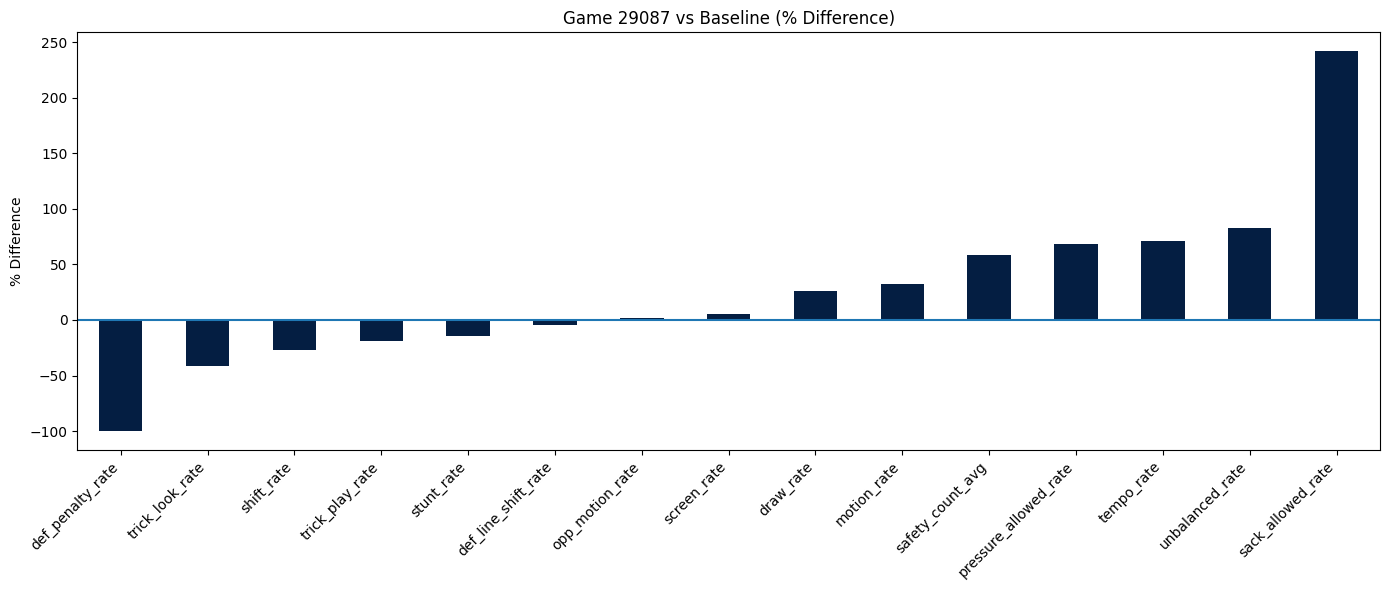

In [135]:
home_tendencies = get_past_tendencies(penn_games, 'All Home Games')
whiteout_tendencies = get_past_tendencies(whiteouts, 'Whiteout Games')

df = whiteout_tendencies[
    (whiteout_tendencies['pff_game_id'] == 29087) |
    (whiteout_tendencies['pff_game_id'] == '-')
][[
    'pff_game_id',
    'motion_rate', 'shift_rate', 'tempo_rate', 'unbalanced_rate',
    'screen_rate', 'draw_rate', 'trick_play_rate', 'trick_look_rate',
    'pressure_allowed_rate', 'sack_allowed_rate', 'stunt_rate',
    'safety_count_avg', 'def_line_shift_rate', 'def_penalty_rate',
    'opp_motion_rate'
]].set_index('pff_game_id')

baseline = df.loc['-']
game = df.loc[29087]

pct_diff = ((game - baseline) / baseline) * 100

pct_diff = pct_diff.replace([float('inf'), -float('inf')], 0).fillna(0)

pct_diff.sort_values().plot(kind='bar', figsize=(14, 6), color='#041E42')

plt.title('Game 29087 vs Baseline (% Difference)')
plt.ylabel('% Difference')
plt.axhline(0)  # baseline reference line
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
final_scores = whiteouts.groupby('pff_game_id').last().reset_index()[['pff_game_id', 'offense', 'defense', 'off_score', 'def_score']]
final_scores

,pff_game_id,offense,defense,off_score,def_score
0,20142,ALAU,PAST,20,28
1,22087,MNUN,PAST,17,45
2,24378,PAST,IAUN,31,0
3,26842,PAST,WAUN,35,6
4,29087,PAST,ORUN,24,30


Included (16):
  off_plays: home=62.900, whiteout=86.600, diff=37.7%
  motion_rate: home=0.580, whiteout=0.423, diff=27.1%
  shift_rate: home=0.104, whiteout=0.055, diff=47.2%
  tempo_rate: home=0.120, whiteout=0.062, diff=47.9%
  unbalanced_rate: home=0.197, whiteout=0.102, diff=48.1%
  screen_rate: home=0.116, whiteout=0.076, diff=34.5%
  draw_rate: home=0.005, whiteout=0.011, diff=115.6%
  trick_play_rate: home=0.037, whiteout=0.049, diff=35.1%
  trick_look_rate: home=0.030, whiteout=0.069, diff=132.6%
  pressure_allowed_rate: home=0.164, whiteout=0.119, diff=27.7%
  sack_allowed_rate: home=0.027, whiteout=0.008, diff=70.7%
  stunt_rate: home=0.226, whiteout=0.150, diff=33.7%
  safety_count_avg: home=1.694, whiteout=1.184, diff=30.1%
  def_line_shift_rate: home=0.021, whiteout=0.011, diff=45.9%
  def_penalty_rate: home=0.033, whiteout=0.024, diff=28.7%
  opp_motion_rate: home=0.322, whiteout=0.211, diff=34.4%
['off_plays', 'motion_rate', 'shift_rate', 'tempo_rate', 'unbalanced_rate'

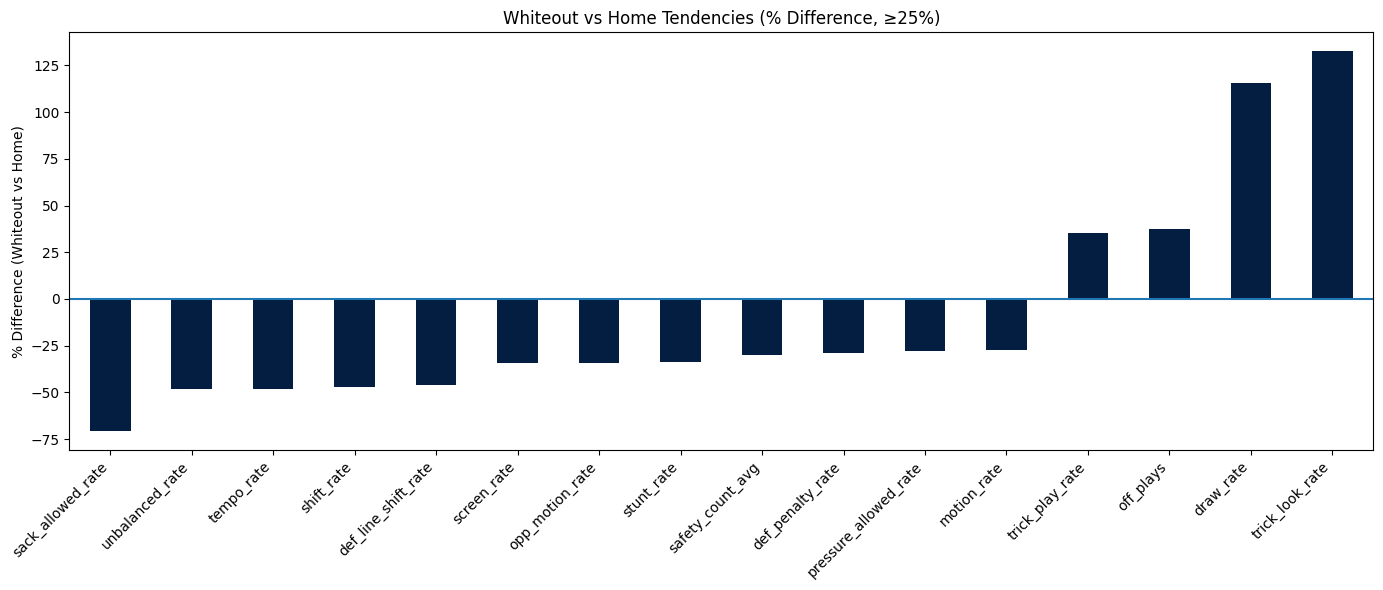

In [136]:
home_totals = home_tendencies[home_tendencies['season'] == 'TOTAL'].iloc[0]
whiteout_totals = whiteout_tendencies[whiteout_tendencies['season'] == 'TOTAL'].iloc[0]
skip_cols = ['season', 'week', 'pff_game_id']
numeric_cols = [col for col in home_tendencies.columns if col not in skip_cols]

included = []
not_included = []

for col in numeric_cols:
    home_val = pd.to_numeric(home_totals[col], errors='coerce')
    whiteout_val = pd.to_numeric(whiteout_totals[col], errors='coerce')
    
    if pd.isna(home_val) or pd.isna(whiteout_val) or home_val == 0:
        not_included.append(col)
        continue
    
    pct_diff = abs(home_val - whiteout_val) / abs(home_val)
    
    if pct_diff >= 0.25:
        included.append(col)
    else:
        not_included.append(col)


print(f"Included ({len(included)}):")
for col in included:
    home_val = pd.to_numeric(home_totals[col], errors='coerce')
    whiteout_val = pd.to_numeric(whiteout_totals[col], errors='coerce')
    pct_diff = abs(home_val - whiteout_val) / abs(home_val) * 100
    print(f"  {col}: home={home_val:.3f}, whiteout={whiteout_val:.3f}, diff={pct_diff:.1f}%")
print(included)

print(f"\nNot Included ({len(not_included)}):")
print(not_included)

diff_data = {}

for col in included:
    home_val = pd.to_numeric(home_totals[col], errors='coerce')
    whiteout_val = pd.to_numeric(whiteout_totals[col], errors='coerce')
    
    pct_diff = (whiteout_val - home_val) / abs(home_val) * 100
    diff_data[col] = pct_diff

diff_series = pd.Series(diff_data).sort_values()

diff_series.plot(kind='bar', figsize=(14, 6), color='#041E42')

plt.title('Whiteout vs Home Tendencies (% Difference, ≥25%)')
plt.ylabel('% Difference (Whiteout vs Home)')
plt.axhline(0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [35]:
# check the totals rows
print("Home totals:")
print(home_totals)
print("\nWhiteout totals:")
print(whiteout_totals)

# check dtypes
print("\nHome tendencies dtypes:")
print(home_tendencies.dtypes)

# check if numeric cols are being detected
print("\nNumeric cols detected:")
print(numeric_cols.tolist())

# manual check on one column
col = 'motion_rate'
print(f"\n{col}:")
print(f"home: {home_totals[col]}, type: {type(home_totals[col])}")
print(f"whiteout: {whiteout_totals[col]}, type: {type(whiteout_totals[col])}")

Home totals:
season                        TOTAL
week                              -
pff_game_id                       -
off_plays                      62.9
pass_rate                  0.470869
run_rate                   0.517906
motion_rate                0.580429
shift_rate                 0.103574
no_huddle_rate                  0.0
tempo_rate                 0.119589
unbalanced_rate            0.196857
play_action_rate           0.166063
screen_rate                0.116311
draw_rate                  0.004889
option_rate                0.134905
rpo_rate                   0.212416
trick_play_rate            0.036596
trick_look_rate            0.029596
pressure_allowed_rate      0.164063
sack_allowed_rate          0.026625
off_penalty_rate           0.021044
def_plays                      66.6
blitz_rate                 0.314006
stunt_rate                 0.226493
pressure_generated_rate    0.205086
sack_generated_rate        0.035342
box_count_avg              6.534546
box_los_count_a

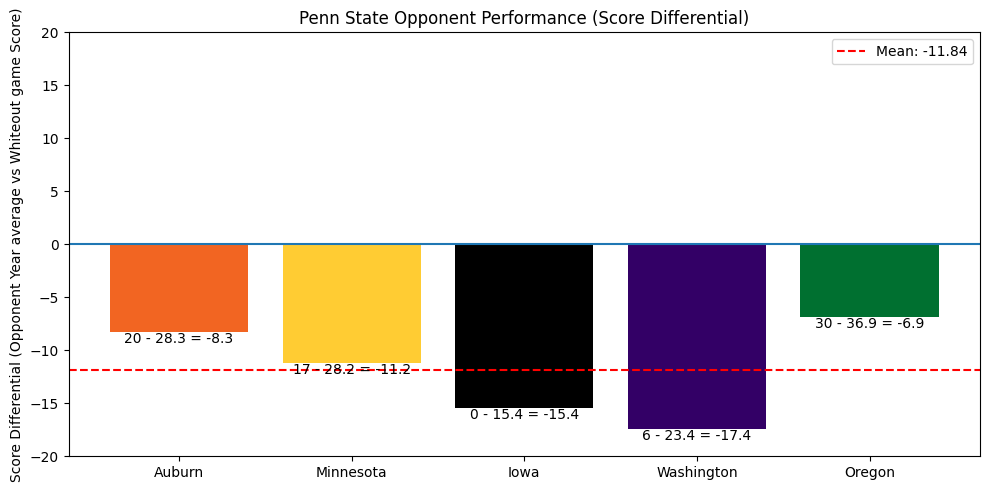

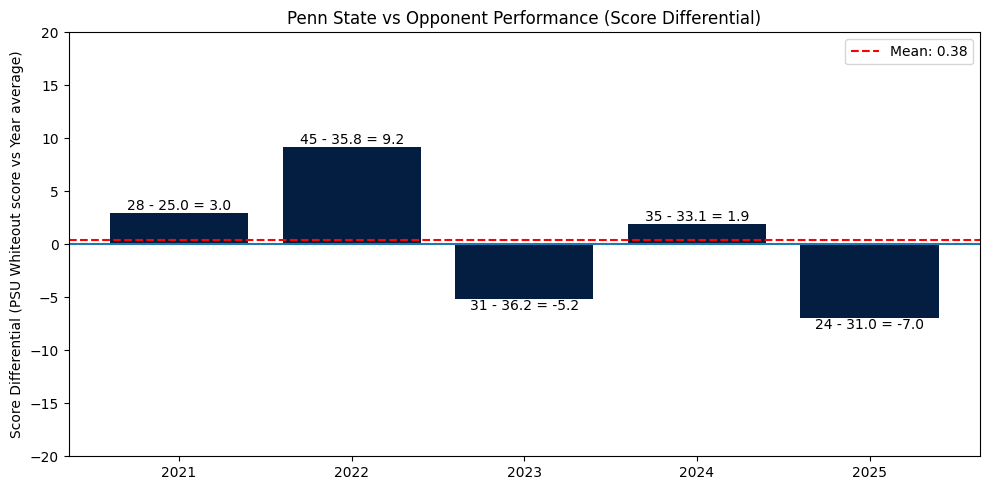

In [107]:

# Create dataframe
df = pd.DataFrame({
    'Year': [2021, 2022, 2023, 2024, 2025],
    'Opponent': ['Auburn', 'Minnesota', 'Iowa', 'Washington', 'Oregon'],
    'PSU_score': [28, 45, 31, 35, 24],
    'PSU_avg': [25, 35.8, 36.2, 33.1, 31],
    'Opp_score': [20, 17, 0, 6, 30],
    'Opp_avg': [28.3, 28.2, 15.4, 23.4, 36.9],
})

# Calculate score difference
df['diff'] = df['Opp_score'] - df['Opp_avg']
df['PSU_diff'] = df['PSU_score'] - df['PSU_avg']

colors = ['#F26522', '#ffcc33', 'black', '#330066', '#007030']

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(df['Opponent'], df['diff'], color=colors)

# Add labels (opp score + avg)
for bar, opp_score, opp_avg in zip(bars, df['Opp_score'], df['Opp_avg']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{opp_score} - {opp_avg} = {round(opp_score-opp_avg, 2)}",
        ha='center',
        va='bottom' if height >= 0 else 'top'
    )

y_mean = np.mean(df['diff'])

# Formatting
plt.ylim(-20, 20)
plt.axhline(0)
plt.axhline(y=y_mean, color='r', linestyle='--', label=f'Mean: {y_mean:.2f}')
plt.title('Penn State Opponent Performance (Score Differential)')
plt.ylabel('Score Differential (Opponent Year average vs Whiteout game Score)')
plt.tight_layout()
plt.legend()
plt.show()

# ---------------------------------

plt.figure(figsize=(10, 5))
bars = plt.bar(df['Year'], df['PSU_diff'], color='#041E42')

# Add labels (opp score + avg)
for bar, PSU_score, PSU_avg in zip(bars, df['PSU_score'], df['PSU_avg']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{PSU_score} - {PSU_avg} = {round(PSU_score-PSU_avg, 2)}",
        ha='center',
        va='bottom' if height >= 0 else 'top'
    )

y_mean = np.mean(df['PSU_diff'])

# Formatting
plt.ylim(-20, 20)
plt.axhline(0)
plt.axhline(y=y_mean, color='r', linestyle='--', label=f'Mean: {y_mean:.2f}')
plt.title('Penn State vs Opponent Performance (Score Differential)')
plt.ylabel('Score Differential (PSU Whiteout score vs Year average)')
plt.tight_layout()
plt.legend()
plt.show()